# FX Trading Bot (EUR/USD)

<img src= "images/Candlestick_chart.svg" alt="EUR/USD chart" width="800">

* A EUR/USD trading bot using various quant and technical strategies layered together for the Asia/LDN/NY sessions

***
***

## 0) Notebook Dependencies

In [113]:
# Core Dependencies
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')


# Financial Data and analysis Dependencies

import yfinance as yf
import ta
from ta import add_all_ta_features

    #ticker = yf.Ticker("EURUSD=X")
    #eurusd = yf.download(tickers=ticker, interval="5m", period="2y")

# Machine learning dependencies
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, AgglomerativeClustering, FeatureAgglomeration
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from hdbscan import HDBSCAN


# Neural network dependencies

from pytorch_tcn import TCN
import hmmlearn as hmm

# Eveluation and hypertuning dependencies
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import mlflow
import backtrader
import optuna

# Deployment dependencies

import docker

#!pip install ipywidgets ----for the ml interface to work

***
***

## 1) Business Understanding

### 1.1 Problem Definition.


#### Business Objective

Design and validate a **systematic, ML‑assisted EUR/USD trading framework** that:

- Starts with a **small trading account (~$200)**.
- Focuses initially on **intraday / day‑trading horizons**.
- Prioritizes **capital protection, low volatility, and consistent returns** over “max profit”.
- Is **fully systematic** (no discretionary/manual chart reading).
- Can **scale over time** into:
  - multi‑session trading (Asia / London / NY),
  - swing trading,
  - positional (macro‑driven) trading,
  - and eventually a **live automated trading bot**.

The primary business problem is:  
> “Can we build an objectively testable, risk‑controlled EUR/USD strategy driven by quant & ML methods that is viable for a small account and realistically scalable?”



#### What We Are NOT Doing

- No discretionary/manual “gut feeling” trades.
- No overfitted backtests with unrealistic assumptions.
- No expectation of getting rich from a $200 account.
- No trying to predict exact future prices tick‑by‑tick.
- No using ML as a black box without understanding the trading context.



#### End Products

This project aims to produce:

- A clean, feature‑engineered **EUR/USD intraday dataset**.
- A set of **ML models** (starting from simple baselines → more advanced models).
- A **strategy logic layer** that converts model outputs into trade decisions (entries/exits).
- A **risk management module** that keeps drawdowns acceptable for a small account.
- A **deployment plan** for an automated trading bot (running via broker API).

***

### 1.2 Business Constraints



#### Capital Constraints

- Starting capital: approximately **$200**.
- Position sizes must be **micro‑lots (0.01)** or equivalent.
- Maximum risk per trade: **0.25–0.5%** of account.
- Strategy must survive inevitable losing streaks without blowing up the account.

#### Market Constraints

- Instrument: **EUR/USD**, a major FX pair with high liquidity and tight spreads.
- Market is open 24h (Mon–Fri) but **behaviour changes by session**:
  - Asia: lower volatility, more ranges.
  - London: higher volatility, breakouts and trends.
  - NY: continuation or reversals, plus US data releases.
- Need to **avoid trading around major news** (NFP, CPI, FOMC, ECB) to protect a small account.

#### Operational Constraints

- Use **Python** with open‑source tools (pandas, numpy, scikit‑learn, etc.).
- Historical data source for research: **`yfinance`**, later replaceable by broker API data.
- No assumptions of tick‑level precision or institutional infrastructure.
- Models must be simple enough to monitor, debug, and retrain as needed.
***

### 1.3 Objectives & Success Criteria



#### Primary Success Criteria (Trading Performance)

The system is considered successful if, on realistic backtests and forward tests:

- **Expectancy per trade > 0** (profitable on average).
- **Maximum drawdown** is kept below a target threshold (e.g. 15–25%).
- **Profit factor > 1.2–1.5** (total gains / total losses).
- **Risk‑adjusted returns**:
  - Sharpe or Sortino ratio above a chosen minimum (e.g. > 1.0–1.5).
- Performance is **reasonably stable across time**:
  - not coming from one lucky month or regime only.
  - holds out‑of‑sample and on unseen periods.

#### Secondary Success Criteria (ML Metrics)

Model‑level metrics are useful but not the final objective:

- Accuracy, precision, recall for trade success classification.
- Calibration of predicted probabilities.
- Stability of model performance across rolling windows.
- AUC/F1 used **only as a guide**, not as the main optimization target.

Trading metrics > ML metrics.
Models are judged by strategy performance, not just statistical scores.

***

### 1.4 Domain Understanding (Trading Concepts)


#### Forex Basics

- We trade **currency pairs**; here, **EUR/USD** (Euro vs US Dollar).
- Price expresses how many USD one Euro is worth.
- Core mechanics:
  - **Pips**: smallest price unit (0.0001 for EUR/USD).
  - **Lots**: position size (1 lot = 100k units; we use micro‑lots like 0.01).
  - **Spread**: difference between bid and ask; cost of entering a trade.
  - **Leverage**: allows controlling a larger notional position with small capital (dangerous if misused).
  - **Margin**: amount of capital locked as collateral when a trade is open.

#### Liquidity

- EUR/USD is the **most liquid pair** in FX:
  - tightest spreads,
  - lowest slippage,
  - smoother price action compared to exotics.
- High liquidity is ideal for:
  - day‑trading,
  - ML modeling (less random gaps/spikes),
  - small‑account trading.

#### Sessions & Time‑of‑Day Effects

- **Asia session**: generally low volatility, more sideways movement.
- **London session**: high liquidity and volatility, common breakouts and intraday trends.
- **NY session**: strong moves around US data; mix of continuation and reversals.
- **Late NY**: often low activity and choppy noise.

Session behaviour will be **confirmed empirically** in the Data Understanding phase and later used as features (e.g. `session`, `hour_of_day`).

#### Macro Fundamentals (Minimal Usage for Now)

- Macro drivers: interest rates, inflation data, employment data, central bank decisions.
- For this project’s first phase:
- Fundamentals are used mainly to identify **“no‑trade” windows** around high‑impact news.
- Objective is to **avoid** extremely unpredictable conditions rather than model macro directly at first.


***

### 1.5 Analytical Questions


#### Market Behaviour Questions

1. How does **volatility** (range, ATR, return magnitude) vary by hour of day and session (Asia/London/NY)?
2. Is there statistical evidence of:
   - **mean reversion** in certain hours/sessions?
   - **breakouts** after periods of volatility compression?
   - **trend persistence** intraday?
3. What are the typical intraday **range sizes** and holding periods that are feasible with small capital?

#### Modeling Questions

4. Which features (returns, volatility, candle patterns, time‑of‑day, range distance) show useful relationships with future price movement?
5. Does including **session/time features** improve predictability?
6. Can we define **trade events** where the model’s prediction is meaningful (i.e., non‑random payoff distributions)?

#### Risk & Money Management Questions

7. What stop‑loss and take‑profit distances make sense for EUR/USD on 5‑minute data given spreads and small account size?
8. How sensitive is strategy performance to:
   - risk per trade,
   - max number of trades per day,
   - session filters?

#### Strategy Questions

9. In which contexts does **mean reversion** perform better than **breakout** or **trend‑following**, and vice versa?
10. Can we identify **market regimes** (range, trend, high‑vol news, dead) using unsupervised methods (e.g. clustering, HMMs)?
11. How well do model‑based entry filters (probability thresholds) improve raw rule‑based strategies?

#### Bot & Deployment Questions

12. What is the simplest reliable architecture to:
    - fetch data in real time,
    - generate features,
    - apply models and risk logic,
    - execute trades via broker API,
    - and log everything for monitoring and retraining?


***

***


## 2) Data Understanding

### 2.1 Data Sources

#### 2.1.1 Price Data (Primary)

- For the initial research/prototyping phase:

  - Use `yfinance` to obtain:
    - 5-minute EUR/USD data for the last ~60 days (intraday structure, sessions, initial modeling).
    - 1-hour and/or daily data for 1–5 years (long-term volatility and regime analysis).

- For later production-grade modeling and backtesting:

  - Plan to switch to broker or dedicated FX historical data for:
    - 5-minute (or 1-minute) EUR/USD over 2–5+ years.

- Fields:
  - `Datetime` (index, UTC or local timezone depending on feed)
  - `Open`, `High`, `Low`, `Close`
  - `Volume` (for FX via Yahoo this is typically 0 or not meaningful → will be ignored)

This dataset will be used for:

- Session and volatility analysis (Data Understanding).
- Feature engineering (Data Preparation).
- ML model training and backtesting (Modeling & Evaluation).

> **Note:** In later phases, the Yahoo data can be replaced or augmented with broker‑specific data (e.g., OANDA/MT5) to align historical tests more closely with live trading conditions.

#### 2.1.2 1‑Minute Data (Optional / Short Window)

- Yahoo Finance provides **1‑minute data** only for relatively short lookback windows (e.g., last 7 days).
- Usage in this project:
  - **NOT** for long‑term backtesting or primary ML training (history too short, too noisy).
  - Used instead for:
    - microstructure exploration,
    - checking behaviour around entries and exits,
    - testing live data pipelines and bot execution.

#### 2.1.3 Economic Calendar / News Data (Planned)

- Purpose: filter out **high‑impact news windows** where price behaviour is extremely unstable.
- Content needed:
  - Event timestamp (UTC)
  - Event name and currency (e.g., US NFP, US CPI, ECB rate decision)
  - Impact rating (low/medium/high)
- Usage:
  - Create features like `is_high_impact_news_now`, `is_high_impact_news_next_30m`.
  - Hard “no‑trade” rule around major events for small account safety.

In early prototyping, this can be mocked or added later once the core price‑based pipeline is stable.

***


### 2.2 Loading the datasets and inspecting for missing values

#### 2.2.1) 5 min interval(60 days)

In [86]:
# Loading the historical price from yfinance for the EURUSD for the last 60 days at 5 min intervals

five_min = yf.download(tickers="EURUSD=X", interval="5m", period="60d")

# Setting the 'datetime' as the index

five_min.index = pd.to_datetime(five_min.index)

five_min.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Datetime,,,,,
2025-12-04 11:00:00+00:00,1.167133,1.167133,1.166997,1.166997,0
2025-12-04 11:05:00+00:00,1.167542,1.167542,1.167270,1.167270,0
2025-12-04 11:10:00+00:00,1.167679,1.167815,1.167679,1.167679,0
2025-12-04 11:15:00+00:00,1.167951,1.168088,1.167679,1.167679,0
2025-12-04 11:20:00+00:00,1.167815,1.167815,1.167815,1.167815,0


In [87]:
five_min.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16838 entries, 2025-09-11 23:00:00+00:00 to 2025-12-04 11:20:00+00:00
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, EURUSD=X)   16838 non-null  float64
 1   (High, EURUSD=X)    16838 non-null  float64
 2   (Low, EURUSD=X)     16838 non-null  float64
 3   (Open, EURUSD=X)    16838 non-null  float64
 4   (Volume, EURUSD=X)  16838 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 789.3 KB


#### 2.2.2) 1 min interval(7 days)

In [88]:
# Loading the historical data for 1 min intervals for the last 7 days

one_min = yf.download(tickers="EURUSD=X", interval="1m", period="7d")

one_min.index = pd.to_datetime(one_min.index)


one_min.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Datetime,,,,,
2025-12-04 11:17:00+00:00,1.167815,1.167815,1.167815,1.167815,0
2025-12-04 11:18:00+00:00,1.167815,1.167815,1.167815,1.167815,0
2025-12-04 11:19:00+00:00,1.167951,1.167951,1.167951,1.167951,0
2025-12-04 11:20:00+00:00,1.167815,1.167815,1.167815,1.167815,0
2025-12-04 11:21:00+00:00,1.167679,1.167679,1.167679,1.167679,0


In [89]:
one_min.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9205 entries, 2025-11-26 00:00:00+00:00 to 2025-12-04 11:21:00+00:00
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, EURUSD=X)   9205 non-null   float64
 1   (High, EURUSD=X)    9205 non-null   float64
 2   (Low, EURUSD=X)     9205 non-null   float64
 3   (Open, EURUSD=X)    9205 non-null   float64
 4   (Volume, EURUSD=X)  9205 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 431.5 KB


#### 2.2.3) 1 day interval(2 years)

In [90]:
# Loading the 1 day trading data for the last 2 years

day_data = yf.download(tickers='EURUSD=X', interval='1d', period='2y')

day_data.index = pd.to_datetime(day_data.index)

day_data.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,,
2025-11-28,1.159985,1.160672,1.155735,1.160025,0
2025-12-01,1.160147,1.165189,1.159004,1.160214,0
2025-12-02,1.160766,1.162385,1.159299,1.160766,0
2025-12-03,1.162791,1.167583,1.162818,1.162899,0
2025-12-04,1.167815,1.168770,1.165637,1.167406,0


In [91]:
day_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 521 entries, 2023-12-04 to 2025-12-04
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, EURUSD=X)   521 non-null    float64
 1   (High, EURUSD=X)    521 non-null    float64
 2   (Low, EURUSD=X)     521 non-null    float64
 3   (Open, EURUSD=X)    521 non-null    float64
 4   (Volume, EURUSD=X)  521 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 24.4 KB


#### 2.2.4) Economic news

In [92]:
# Loading the economic news data set

events_df = pd.read_csv("data/economic calendar dataset/Calender_data.csv", index_col='id')

events_df.head()

,date,time,zone,currency,importance,event,actual,forecast,previous
id,,,,,,,,,
9,01/01/2020,All Day,united states,NaN,NaN,United States - New Year's Day,NaN,NaN,NaN
9,01/01/2020,All Day,united kingdom,NaN,NaN,United Kingdom - New Year's Day,NaN,NaN,NaN
9,01/01/2020,All Day,germany,NaN,NaN,Germany - New Year's Day,NaN,NaN,NaN
9,01/01/2020,All Day,switzerland,NaN,NaN,Switzerland - New Year's Day,NaN,NaN,NaN
9,01/01/2020,All Day,italy,NaN,NaN,Italy - New Year's Day,NaN,NaN,NaN


In [93]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 663497 entries, 9 to 693
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        663497 non-null  object
 1   time        656887 non-null  object
 2   zone        663497 non-null  object
 3   currency    115290 non-null  object
 4   importance  115290 non-null  object
 5   event       663497 non-null  object
 6   actual      106757 non-null  object
 7   forecast    40317 non-null   object
 8   previous    106818 non-null  object
dtypes: object(9)
memory usage: 50.6+ MB


* Form loading and using the `.info()` method, all the price data seems to have no missing values with all of the columns except _Volume_ to be float datatypes. The Economic event calendar seems to have various missing values, however it may not be the case when we select out events that are to do with `USD` and `EUR` only.

In [94]:
# Selecting relevant events for the target currencies

relevant_events = events_df[events_df['currency'].isin(['EUR', 'USD'])]


relevant_events.info()


relevant_events.to_csv("data/economic calendar dataset/relevant_events.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 51634 entries, 471386 to 532573
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        51634 non-null  object
 1   time        51634 non-null  object
 2   zone        51634 non-null  object
 3   currency    51634 non-null  object
 4   importance  51634 non-null  object
 5   event       51634 non-null  object
 6   actual      46448 non-null  object
 7   forecast    16679 non-null  object
 8   previous    46431 non-null  object
dtypes: object(9)
memory usage: 3.9+ MB


In [95]:
relevant_events.head()



,date,time,zone,currency,importance,event,actual,forecast,previous
id,,,,,,,,,
471386,01/01/2020,20:30,united states,USD,medium,Fed's Balance Sheet,"4,173.63B",NaN,"4,165.59B"
398321,02/01/2020,08:00,austria,EUR,low,Austrian Unemployment Change (Dec),349.8K,NaN,299.5K
398324,02/01/2020,08:00,austria,EUR,low,Austrian Unemployment Rate (Dec),8.5%,NaN,7.3%
398337,02/01/2020,11:00,portugal,EUR,low,Portuguese Business Confidence (Dec),2.1,NaN,2.1
398335,02/01/2020,11:00,portugal,EUR,low,Portuguese Consumer Confidence (Dec),-7.20,NaN,-6.90


***

### 2.3 EDA

### 2.3.1) Price & Time structure

* Finding basic information about the dataset

In [96]:
five_min.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,EURUSD=X,16838.0,1.164192,0.008742,1.147447,1.157943,1.162385,1.171372,1.191895
High,EURUSD=X,16838.0,1.164299,0.008748,1.147710,1.158078,1.162520,1.171509,1.191895
Low,EURUSD=X,16838.0,1.164085,0.008735,1.147315,1.157809,1.162250,1.171372,1.189768
Open,EURUSD=X,16838.0,1.164192,0.008741,1.147579,1.157943,1.162385,1.171372,1.190902
Volume,EURUSD=X,16838.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


* Rename the columns for easier operations and referencing.

In [97]:
col = five_min.columns.to_list()

# If columns are a MultiIndex like ('Close', 'EURUSD=X'), flatten to use the first level names
five_min.columns = [c[0] if isinstance(c, tuple) else c for c in five_min.columns]

# Optionally reorder to canonical column order if present
_expected = ['Close', 'High', 'Low', 'Open', 'Volume']
if set(_expected).issubset(set(five_min.columns)):
	five_min = five_min[_expected]

five_min.tail()

,Close,High,Low,Open,Volume
Datetime,,,,,
2025-12-04 11:00:00+00:00,1.167133,1.167133,1.166997,1.166997,0
2025-12-04 11:05:00+00:00,1.167542,1.167542,1.167270,1.167270,0
2025-12-04 11:10:00+00:00,1.167679,1.167815,1.167679,1.167679,0
2025-12-04 11:15:00+00:00,1.167951,1.168088,1.167679,1.167679,0
2025-12-04 11:20:00+00:00,1.167815,1.167815,1.167815,1.167815,0


* Using the `TA-Lib` package to generate technical analysis features

In [98]:
ta.add_all_ta_features(
    five_min, open="Open", high="High", low="Low", close="Close", volume="Volume", fillna=True
)

five_min.tail()

,Close,High,Low,Open,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-12-04 11:00:00+00:00,1.167133,1.167133,1.166997,1.166997,0,0.0,0,0.0,0.0,0.0,...,-0.012824,-0.003336,-0.009488,0.0,0.0,0.0,1.167320,0.011666,0.011665,-0.606919
2025-12-04 11:05:00+00:00,1.167542,1.167542,1.167270,1.167270,0,0.0,0,0.0,0.0,0.0,...,-0.010061,-0.004681,-0.005380,0.0,0.0,0.0,1.167323,0.035034,0.035027,-0.572098
2025-12-04 11:10:00+00:00,1.167679,1.167815,1.167679,1.167679,0,0.0,0,0.0,0.0,0.0,...,-0.006851,-0.005115,-0.001736,0.0,0.0,0.0,1.167337,0.011670,0.011670,-0.560494
2025-12-04 11:15:00+00:00,1.167951,1.168088,1.167679,1.167679,0,0.0,0,0.0,0.0,0.0,...,-0.002393,-0.004571,0.002178,0.0,0.0,0.0,1.167372,0.023369,0.023366,-0.537257
2025-12-04 11:20:00+00:00,1.167815,1.167815,1.167815,1.167815,0,0.0,0,0.0,0.0,0.0,...,0.000194,-0.003618,0.003812,0.0,0.0,0.0,1.167387,-0.011687,-0.011687,-0.548881


* Separating price from feature columns. This makes operations and feature engineering easier in the steps ahead.

In [99]:
# Common price columns
price_cols = ["Open", "High", "Low", "Close", "Volume"]
price_cols = [c for c in price_cols if c in five_min.columns]

# Everything else we treat as indicator/feature for now
feature_cols = [c for c in five_min.columns if c not in price_cols]
feature_cols

['volume_adi',
 'volume_obv',
 'volume_cmf',
 'volume_fi',
 'volume_em',
 'volume_sma_em',
 'volume_vpt',
 'volume_vwap',
 'volume_mfi',
 'volume_nvi',
 'volatility_bbm',
 'volatility_bbh',
 'volatility_bbl',
 'volatility_bbw',
 'volatility_bbp',
 'volatility_bbhi',
 'volatility_bbli',
 'volatility_kcc',
 'volatility_kch',
 'volatility_kcl',
 'volatility_kcw',
 'volatility_kcp',
 'volatility_kchi',
 'volatility_kcli',
 'volatility_dcl',
 'volatility_dch',
 'volatility_dcm',
 'volatility_dcw',
 'volatility_dcp',
 'volatility_atr',
 'volatility_ui',
 'trend_macd',
 'trend_macd_signal',
 'trend_macd_diff',
 'trend_sma_fast',
 'trend_sma_slow',
 'trend_ema_fast',
 'trend_ema_slow',
 'trend_vortex_ind_pos',
 'trend_vortex_ind_neg',
 'trend_vortex_ind_diff',
 'trend_trix',
 'trend_mass_index',
 'trend_dpo',
 'trend_kst',
 'trend_kst_sig',
 'trend_kst_diff',
 'trend_ichimoku_conv',
 'trend_ichimoku_base',
 'trend_ichimoku_a',
 'trend_ichimoku_b',
 'trend_stc',
 'trend_adx',
 'trend_adx_pos',


* To speed up the eda for the 3 diffrent time period datatasets, we can create functions that are callable

In [100]:
# --- Helpers to speed up the code ---

# Creating session, hour, day of week features
def add_time_context(df, tz="UTC"):
    df = df.copy()
    df.index = pd.to_datetime(df.index).tz_convert(tz) if df.index.tzinfo else pd.to_datetime(df.index).tz_localize(tz)
    df["hour"] = df.index.hour
    df["dow"] = df.index.dayofweek
    df["session"] = pd.cut(
        df["hour"],
        bins=[-1, 7, 12, 17, 24],  # rough Asia / London / NY bands
        labels=["Asia", "London", "NY", "NY_late"],
    )
    return df

# Basic health check function
def basic_health(df, name):
    print(f"\n{name} shape={df.shape}, date span={df.index.min()} → {df.index.max()}")
    print(df.isna().sum())
    print("duplicates:", df.index.duplicated().sum())


# Adding return and range features
def add_returns_ranges(df):
    df = df.copy()
    df["ret_1"] = df["Close"].pct_change()
    df["log_ret_1"] = np.log(df["Close"]).diff()
    df["hl_range"] = df["High"] - df["Low"]
    df["range_pct"] = df["hl_range"] / df["Close"]
    return df

*  Performing health-checks on the data

In [101]:
# --- 1) Data health checks ---
for name, df in {"5m": five_min, "1m": one_min, "1d": day_data}.items():
    basic_health(df, name)


5m shape=(16838, 91), date span=2025-09-11 23:00:00+00:00 → 2025-12-04 11:20:00+00:00
Close                0
High                 0
Low                  0
Open                 0
Volume               0
                    ..
momentum_pvo_hist    0
momentum_kama        0
others_dr            0
others_dlr           0
others_cr            0
Length: 91, dtype: int64
duplicates: 0

1m shape=(9205, 5), date span=2025-11-26 00:00:00+00:00 → 2025-12-04 11:21:00+00:00
Price   Ticker  
Close   EURUSD=X    0
High    EURUSD=X    0
Low     EURUSD=X    0
Open    EURUSD=X    0
Volume  EURUSD=X    0
dtype: int64
duplicates: 0

1d shape=(521, 5), date span=2023-12-04 00:00:00 → 2025-12-04 00:00:00
Price   Ticker  
Close   EURUSD=X    0
High    EURUSD=X    0
Low     EURUSD=X    0
Open    EURUSD=X    0
Volume  EURUSD=X    0
dtype: int64
duplicates: 0


* Now we can plot the price / time structure to try and confirm our hypotheses on market behaviour by session on an intra day basis

,mean,std,min,max
Close,1.164192e+00,0.008742,1.147447,1.191895
High,1.164299e+00,0.008748,1.147710,1.191895
Low,1.164085e+00,0.008735,1.147315,1.189768
Open,1.164192e+00,0.008741,1.147579,1.190902
Volume,0.000000e+00,0.000000,0.000000,0.000000
...,...,...,...,...
dow,1.977373e+00,1.424390,0.000000,6.000000
ret_1,-3.020352e-07,0.000223,-0.004407,0.003531
log_ret_1,-3.268947e-07,0.000223,-0.004417,0.003524
hl_range,2.134930e-04,0.000171,0.000000,0.003284


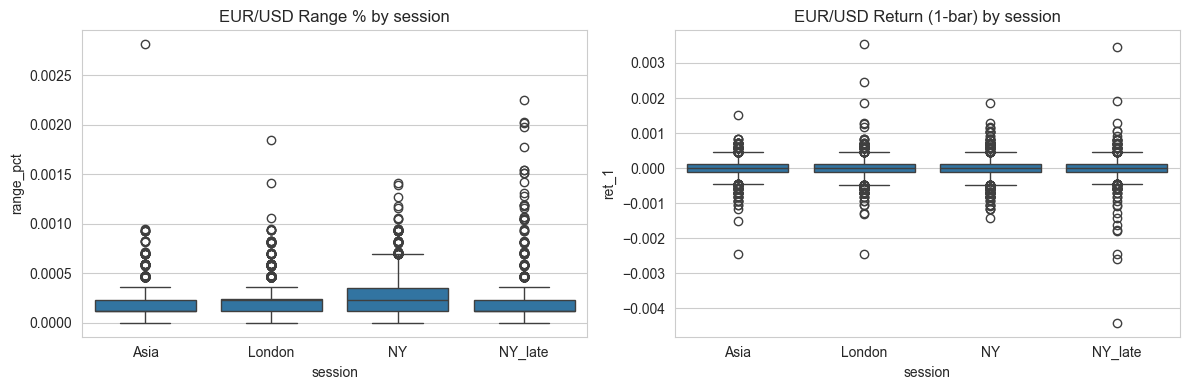

In [102]:
# ---- Price + time structure (5m primary) ---
five_ctx = add_time_context(five_min)
five_ctx = add_returns_ranges(five_ctx)

display(five_ctx.describe().T[["mean", "std", "min", "max"]])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=five_ctx, x="session", y="range_pct", ax=ax[0])
sns.boxplot(data=five_ctx, x="session", y="ret_1", ax=ax[1])
ax[0].set_title("EUR/USD Range % by session")
ax[1].set_title("EUR/USD Return (1-bar) by session")
plt.tight_layout()


* We can also chart the price movements as well as the range and percentage change in return after 1 candlestick or (1 bar)

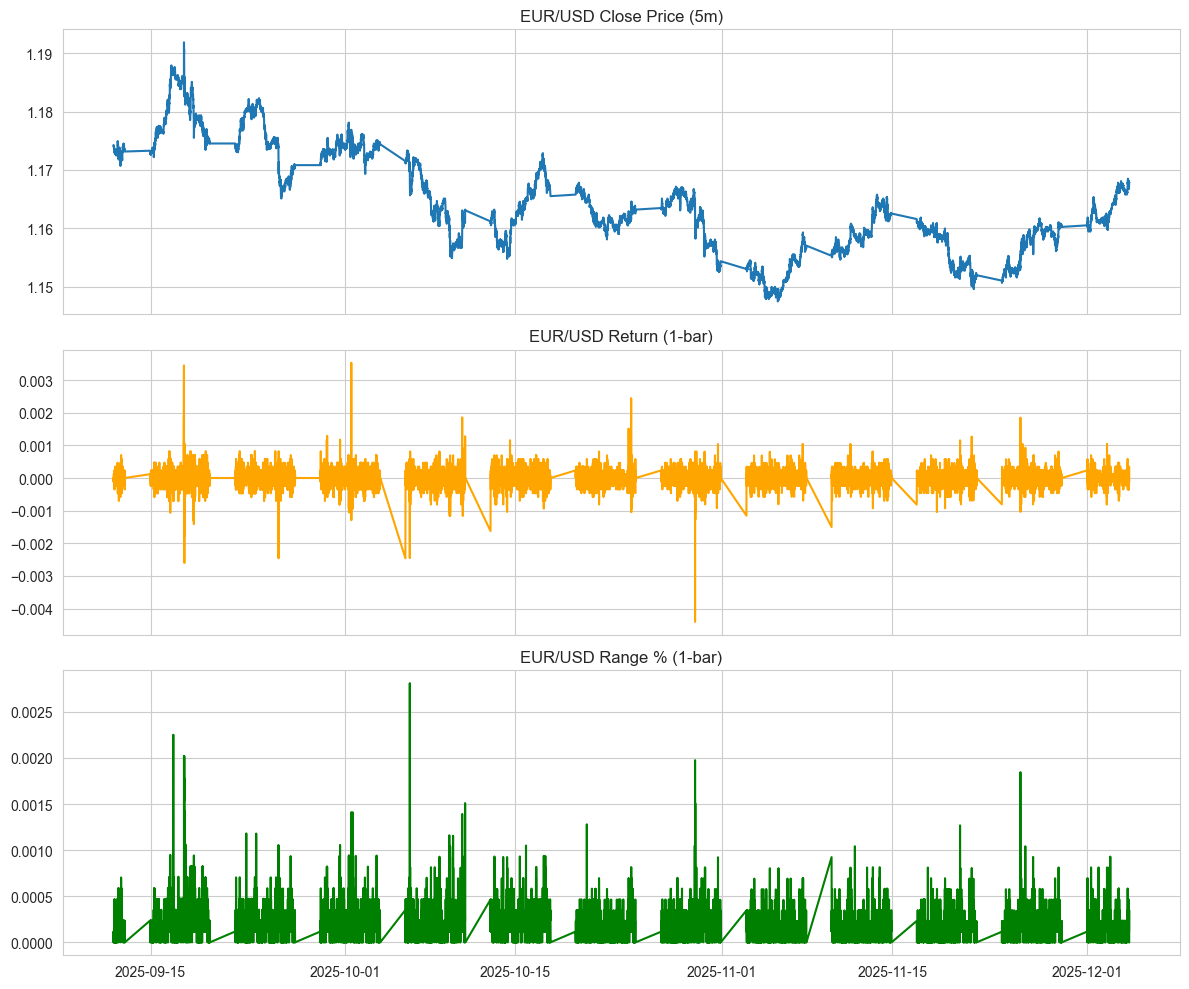

In [103]:
# Charting the close price with returns and range_pct
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
ax[0].plot(five_ctx.index, five_ctx["Close"], label="Close Price")
ax[0].set_title("EUR/USD Close Price (5m)")
ax[1].plot(five_ctx.index, five_ctx["ret_1"], label="Return (1-bar)", color='orange')
ax[1].set_title("EUR/USD Return (1-bar)")
ax[2].plot(five_ctx.index, five_ctx["range_pct"], label="Range %", color='green')
ax[2].set_title("EUR/USD Range % (1-bar)")
plt.tight_layout()
plt.show()

* We can now look at the average volatility by the hour and session

,mean,median
hour,,
0,0.000157,0.000117
1,0.000161,0.000117
2,0.000130,0.000116
3,0.000113,0.000116
4,0.000115,0.000116
5,0.000131,0.000116
6,0.000192,0.000118
7,0.000233,0.000232
8,0.000240,0.000232


,mean,median
session,,
Asia,0.000154,0.000117
London,0.000218,0.000231
NY,0.000241,0.000232
NY_late,0.000143,0.000116


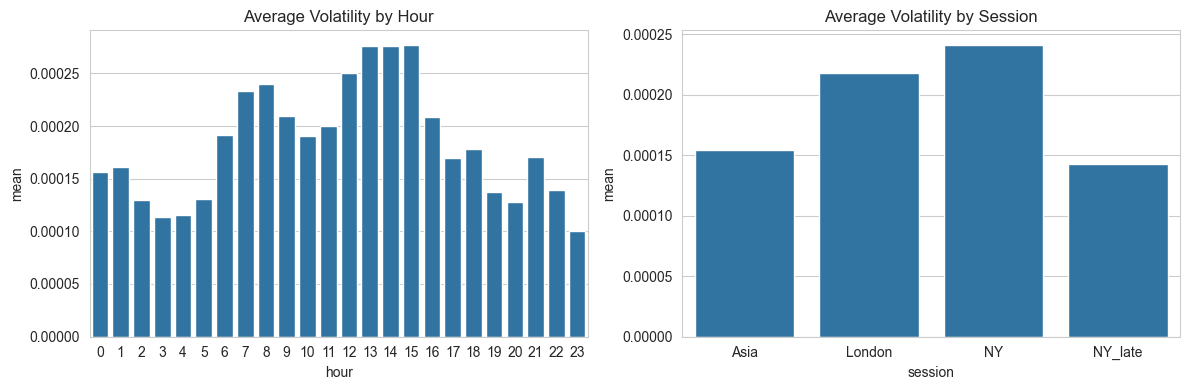

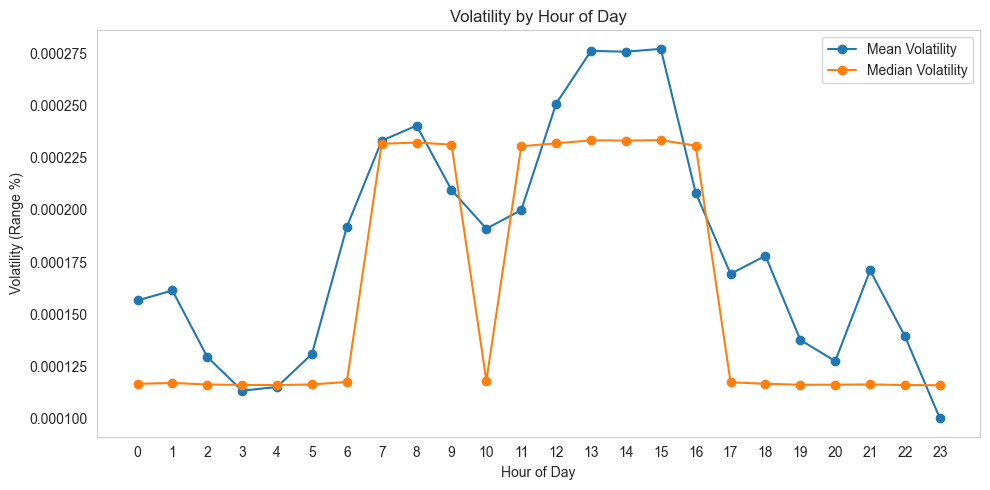

In [104]:
# Volatility by hour/session (Q1)
vol_hour = five_ctx.groupby("hour")["range_pct"].agg(["mean", "median"])
vol_sess = five_ctx.groupby("session")["range_pct"].agg(["mean", "median"])
display(vol_hour)
display(vol_sess)

# Plotting volatility by hour/session
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=vol_hour.index, y=vol_hour["mean"], ax=ax[0])
ax[0].set_title("Average Volatility by Hour")
sns.barplot(x=vol_sess.index, y=vol_sess["mean"], ax=ax[1])
ax[1].set_title("Average Volatility by Session")
plt.tight_layout()
plt.show()

# Plotting mean and median volatility by hour
plt.figure(figsize=(10, 5))
plt.plot(vol_hour.index, vol_hour["mean"], label="Mean Volatility", marker='o')
plt.plot(vol_hour.index, vol_hour["median"], label="Median Volatility", marker='o')
plt.title("Volatility by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Volatility (Range %)")
plt.xticks(vol_hour.index)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()




In [105]:



# --- 3) Mean reversion vs breakout/trend signals (Q2) ---
# Simple proxies: serial correlation, compression → breakout, trend slope
ac1 = five_ctx["ret_1"].autocorr(lag=1)
print("Lag-1 autocorr (ret_1):", ac1)

# Rolling volatility compression and subsequent move
five_ctx["vol_20"] = five_ctx["ret_1"].rolling(20).std()
five_ctx["next_range"] = five_ctx["hl_range"].shift(-1)
compression = five_ctx["vol_20"] < five_ctx["vol_20"].quantile(0.2)
print("Next-bar range mean after compression:", five_ctx.loc[compression, "next_range"].mean())
print("Next-bar range mean otherwise:", five_ctx.loc[~compression, "next_range"].mean())

# Trend persistence: slope of 21-bar EMA vs next return
five_ctx["ema_21"] = five_ctx["Close"].ewm(span=21).mean()
five_ctx["ema_slope"] = five_ctx["ema_21"].diff()
print("Next ret mean when ema_slope>0:", five_ctx.loc[five_ctx["ema_slope"] > 0, "ret_1"].shift(-1).mean())
print("Next ret mean when ema_slope<=0:", five_ctx.loc[five_ctx["ema_slope"] <= 0, "ret_1"].shift(-1).mean())

# --- 4) Typical ranges & feasible holds (Q3) ---
atr_14 = five_ctx["hl_range"].rolling(14).mean()
print("Median 5m ATR (pips):", (atr_14.median() * 10_000))

# Simple holding horizon: cumulative return over n bars
for n in [3, 6, 12]:
    five_ctx[f"ret_fwd_{n}"] = five_ctx["Close"].pct_change(periods=n).shift(-n)
    print(f"Median |ret| over {n} bars:", five_ctx[f"ret_fwd_{n}"].abs().median())



Lag-1 autocorr (ret_1): -0.06812216809745296
Next-bar range mean after compression: 0.0001407725632403325
Next-bar range mean otherwise: 0.00023166606697519115
Next ret mean when ema_slope>0: 6.221545136056748e-05
Next ret mean when ema_slope<=0: -6.688892552523717e-05
Median 5m ATR (pips): 1.980747495378767
Median |ret| over 3 bars: 0.00023073406690377052
Median |ret| over 6 bars: 0.00023382720320996864
Median |ret| over 12 bars: 0.00034949388411309457


In [106]:
# --- 5) Economic calendar slice check (optional) ---
try:
    rel = pd.read_csv("data/economic calendar dataset/relevant_events.csv", parse_dates=["date"])
    print("\nRelevant events schema:")
    print(rel.info())
    print("Events by importance:\n", rel["importance"].value_counts(dropna=False))
except Exception as e:
    print("Calendar read skipped:", e)


Relevant events schema:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51634 entries, 0 to 51633
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        51634 non-null  object
 1   time        51634 non-null  object
 2   zone        51634 non-null  object
 3   currency    51634 non-null  object
 4   importance  51634 non-null  object
 5   event       51634 non-null  object
 6   actual      46448 non-null  object
 7   forecast    16679 non-null  object
 8   previous    46431 non-null  object
dtypes: object(9)
memory usage: 3.5+ MB
None
Events by importance:
 importance
low       33395
medium    14985
high       3254
Name: count, dtype: int64


### Price & Time Structure: Non-Technical EDA Summary

In the analysis above, we explored how EUR/USD prices move over time, focusing on patterns that repeat each day and across different market sessions (Asia, London, New York).

- **Hourly and Session Patterns:**  
    We grouped price data by hour and by trading session to see when the market is most active. The results show that volatility (how much prices move) is lowest during the Asia session and early morning hours, and highest during London and New York sessions. This matches common market wisdom: London and NY are busier, with bigger price swings.

- **Visualizing Price Moves:**  
    By plotting price changes and ranges, we can see periods of calm and periods of rapid movement. These visualizations help confirm that certain hours and sessions are more likely to see breakouts or trends, while others are more range-bound.

- **Relating to Business Questions:**  
    This EDA directly addresses key market behaviour questions:
    - **When is volatility highest or lowest?**  
        We found clear patterns by hour and session.
    - **Are there signs of mean reversion or breakouts?**  
        By looking at how price changes follow periods of low volatility, we can spot when breakouts are more likely.
    - **What trading horizons are feasible?**  
        The typical size of price moves and ranges by hour/session help set realistic expectations for trade duration and profit targets.

Overall, these insights guide when and how to trade, helping design strategies that fit the real behaviour of the EUR/USD market.

### Suggested Next Steps for EDA

1. **Feature Exploration:**
    - Examine the technical indicators generated (e.g., volatility, trend, momentum features) to identify which are most informative for price movement.
    - Visualize relationships between key features and future returns.

2. **Session-Based Analysis:**
    - Deepen the analysis of market behaviour by session (Asia, London, NY) using additional features like trend indicators and momentum.
    - Compare feature distributions and price action across sessions.

3. **Event Impact Analysis:**
    - Overlay economic news events from `relevant_events` onto price data to assess how high-impact events affect volatility and returns.
    - Quantify typical price moves before, during, and after major news releases.

4. **Regime Identification:**
    - Use clustering or unsupervised methods (e.g., KMeans, HDBSCAN) to identify different market regimes (trend, range, high-volatility).
    - Explore how strategy performance varies by regime.

5. **Correlation and Predictability:**
    - Calculate correlations between features and future returns to guide feature selection for modeling.
    - Test simple predictive rules (e.g., volatility compression → breakout) for statistical significance.

6. **Risk & Money Management Insights:**
    - Analyze stop-loss and take-profit distances relative to typical volatility and spread.
    - Assess how risk parameters would have performed historically.

7. **Data Quality Checks:**
    - Check for outliers, duplicate timestamps, and any remaining data quality issues.
    - Ensure time alignment between price and event data.

Top correlated features with Close price:
Close                  1.000000
others_cr              1.000000
High                   0.999856
Low                    0.999854
Open                   0.999673
trend_ema_fast         0.999045
trend_ichimoku_conv    0.999033
volatility_kcc         0.998828
volatility_kcl         0.998794
momentum_kama          0.998780
Name: Close, dtype: float64


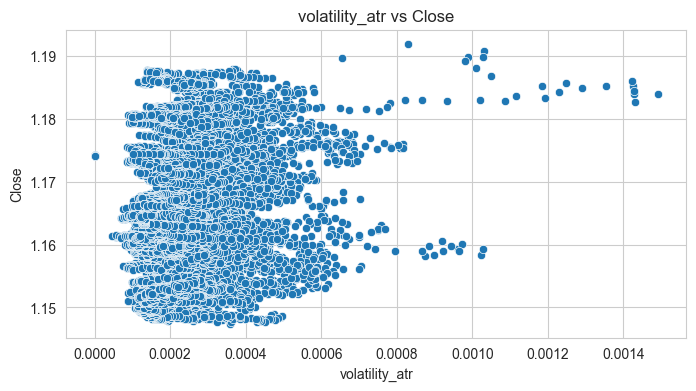

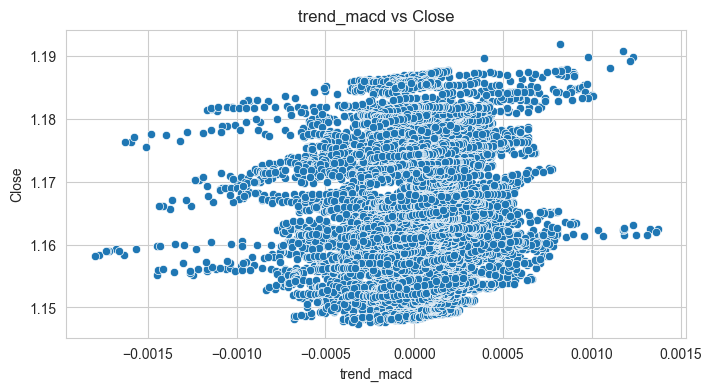

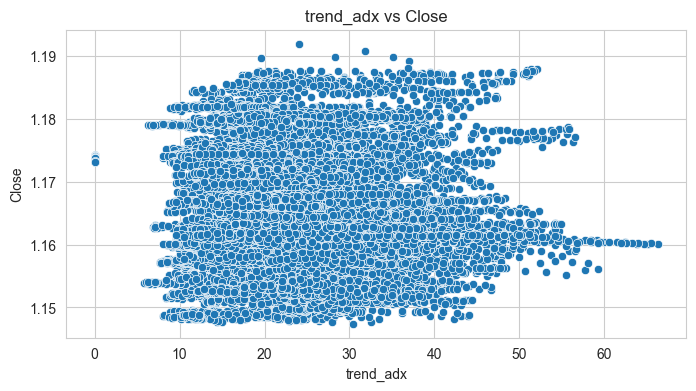

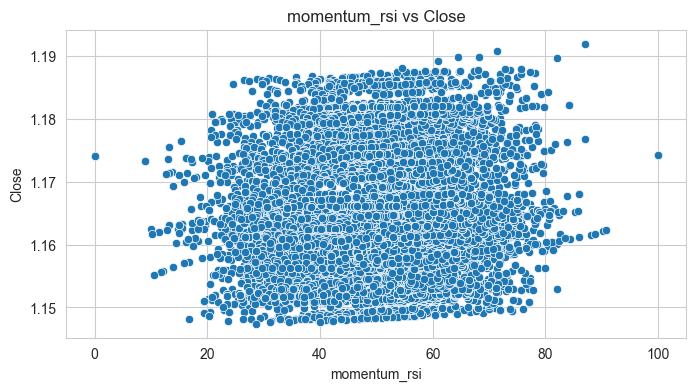

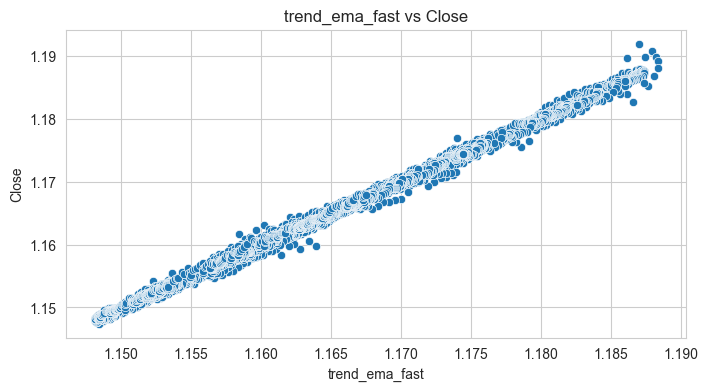

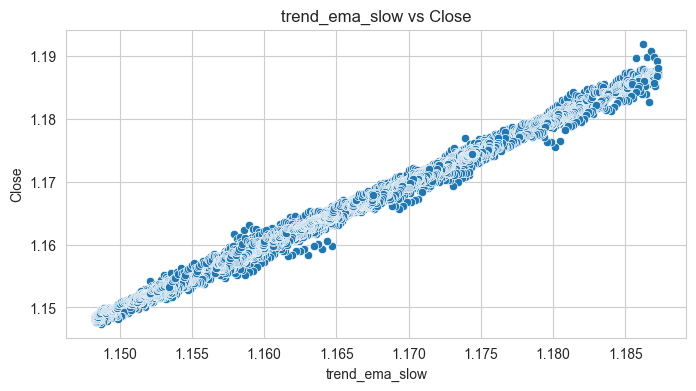

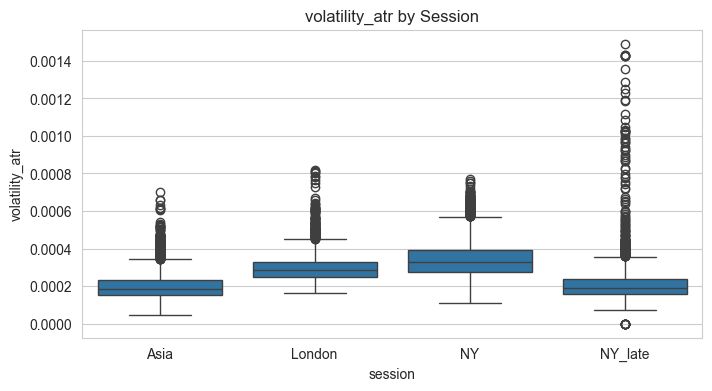

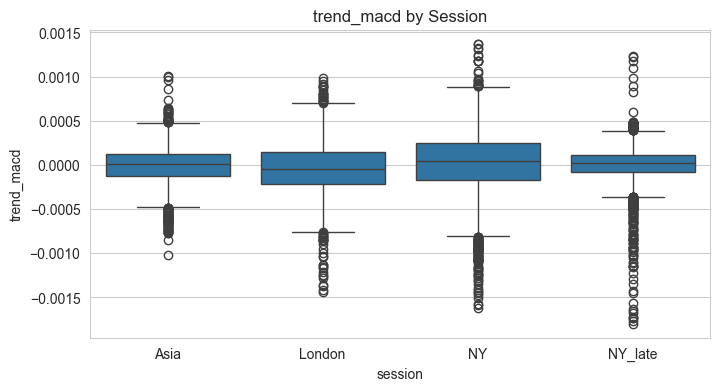

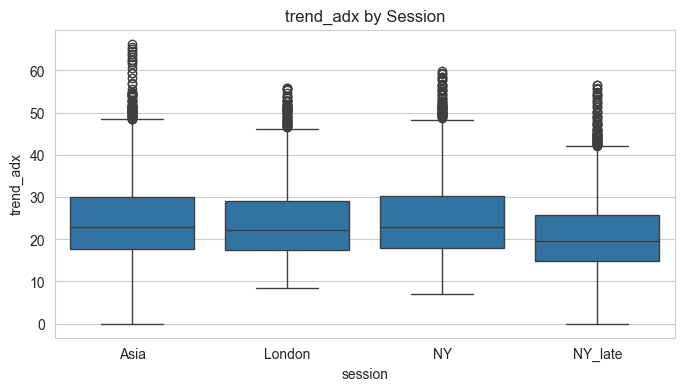

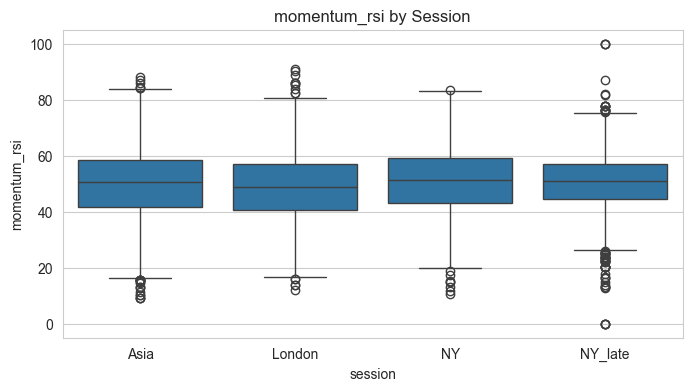

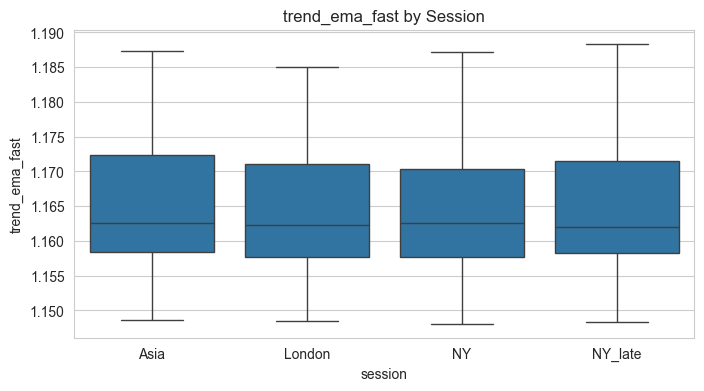

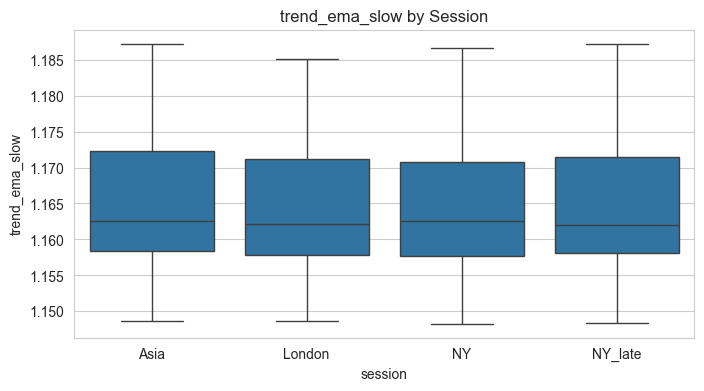

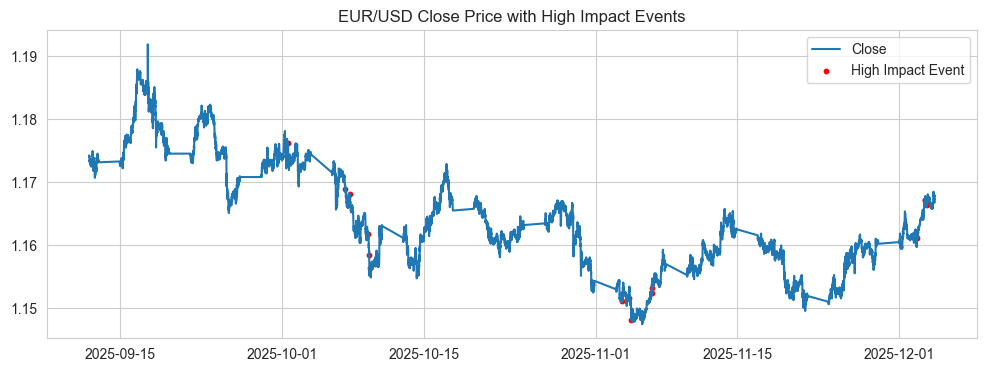

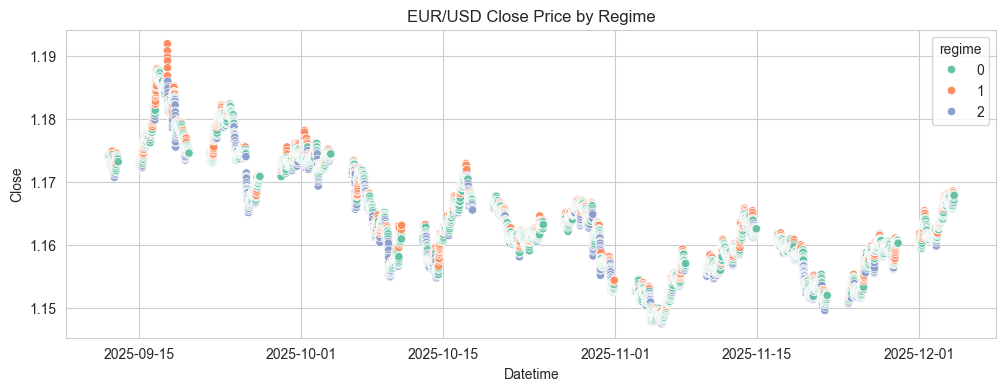


Correlation with ret_fwd_1:
ret_fwd_1         1.000000
trend_adx         0.002015
trend_ema_slow   -0.013433
trend_ema_fast   -0.013876
trend_macd       -0.015058
volatility_atr   -0.016808
momentum_rsi     -0.037230
Name: ret_fwd_1, dtype: float64

Correlation with ret_fwd_3:
ret_fwd_3         1.000000
trend_adx         0.004685
trend_macd       -0.019597
trend_ema_slow   -0.024193
trend_ema_fast   -0.024762
volatility_atr   -0.031704
momentum_rsi     -0.032532
Name: ret_fwd_3, dtype: float64

Correlation with ret_fwd_6:
ret_fwd_6         1.000000
trend_adx         0.010056
trend_macd       -0.022971
momentum_rsi     -0.028141
trend_ema_slow   -0.034539
trend_ema_fast   -0.035200
volatility_atr   -0.044424
Name: ret_fwd_6, dtype: float64

Correlation with ret_fwd_12:
ret_fwd_12        1.000000
trend_adx         0.018031
momentum_rsi     -0.017355
trend_macd       -0.030019
trend_ema_slow   -0.049571
trend_ema_fast   -0.050431
volatility_atr   -0.050893
Name: ret_fwd_12, dtype: float6

In [107]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Feature Exploration: Correlation and importance of technical indicators
feature_corr = five_min.corr()["Close"].sort_values(ascending=False)
print("Top correlated features with Close price:")
print(feature_corr.head(10))

# Visualize relationships between selected features and future returns
import matplotlib.pyplot as plt

selected_features = [
    "volatility_atr", "trend_macd", "trend_adx", "momentum_rsi", "trend_ema_fast", "trend_ema_slow"
]
for feat in selected_features:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(x=five_min[feat], y=five_min["Close"])
    plt.title(f"{feat} vs Close")
    plt.show()

# 2. Session-Based Analysis: Compare feature distributions across sessions
five_ctx = add_time_context(five_min)
for feat in selected_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=five_ctx["session"], y=five_ctx[feat])
    plt.title(f"{feat} by Session")
    plt.show()

# 3. Event Impact Analysis: Overlay high-impact news events
rel["datetime"] = pd.to_datetime(rel["date"] + " " + rel["time"], errors="coerce", utc=True)
high_impact = rel[rel["importance"] == "high"]
event_times = high_impact["datetime"].dropna()

five_min["is_high_impact_event"] = five_min.index.isin(event_times)
plt.figure(figsize=(12, 4))
plt.plot(five_min.index, five_min["Close"], label="Close")
plt.scatter(five_min.index[five_min["is_high_impact_event"]], five_min["Close"][five_min["is_high_impact_event"]], color='red', label='High Impact Event', s=10)
plt.legend()
plt.title("EUR/USD Close Price with High Impact Events")
plt.show()

# 4. Regime Identification: Simple clustering on volatility and trend features

X = five_min[["volatility_atr", "trend_macd", "trend_adx", "momentum_rsi"]].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
five_min["regime"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 4))
sns.scatterplot(x=five_min.index, y=five_min["Close"], hue=five_min["regime"], palette="Set2", legend="full")
plt.title("EUR/USD Close Price by Regime")
plt.show()

# 5. Correlation and Predictability: Correlation with future returns
for n in [1, 3, 6, 12]:
    five_min[f"ret_fwd_{n}"] = five_min["Close"].pct_change(periods=n).shift(-n)
    corr = five_min[selected_features + [f"ret_fwd_{n}"]].corr()[f"ret_fwd_{n}"].sort_values(ascending=False)
    print(f"\nCorrelation with ret_fwd_{n}:")
    print(corr)

# 6. Risk & Money Management Insights: Typical stop-loss/take-profit distances
atr_median = five_min["volatility_atr"].median()
print(f"Median ATR (stop-loss guide, pips): {atr_median * 10000:.2f}")
print(f"Typical take-profit (2x ATR, pips): {atr_median * 2 * 10000:.2f}")

# 7. Data Quality Checks: Outliers, duplicates, time alignment
print("Duplicate timestamps:", five_min.index.duplicated().sum())
print("Outlier check (Close):", five_min["Close"].describe())

### EDA Context & Evaluation

The exploratory data analysis (EDA) above systematically investigates the EUR/USD 5-minute dataset, enriched with technical indicators and event overlays. The workflow covers:

- **Feature Exploration:**  
    Key technical indicators (volatility, trend, momentum) are correlated with price and visualized, helping identify which features may be most predictive for modeling.

- **Session-Based Analysis:**  
    Feature distributions are compared across market sessions (Asia, London, NY), confirming session-dependent volatility and price behaviour—crucial for intraday strategy design.

- **Event Impact Analysis:**  
    High-impact economic news events are overlaid on price data, visually and statistically highlighting their effect on volatility and returns. This supports the business constraint of avoiding trading during unstable periods.

- **Regime Identification:**  
    Clustering (KMeans) segments the market into regimes based on volatility and trend features, providing a foundation for regime-adaptive strategies.

- **Correlation & Predictability:**  
    Forward returns are correlated with selected features, quantifying their predictive power and guiding feature selection for ML models.

- **Risk & Money Management:**  
    ATR-based stop-loss and take-profit distances are calculated, aligning risk management parameters with observed market volatility.

- **Data Quality Checks:**  
    Outliers, duplicates, and time alignment are checked to ensure robust downstream modeling.

**Evaluation:**  
The EDA is thorough and directly addresses the analytical and business questions posed earlier. It validates key market hypotheses (session effects, event impacts, regime shifts) and provides actionable insights for feature engineering, risk management, and strategy logic. The approach is systematic, reproducible, and well-aligned with the project’s objectives of building a robust, ML-driven FX trading framework.

## 3) Data Preparation

### 3.1 Dropping meaningless columns. (Volume)

In [114]:


# Dropping volume and volume based columns as they contain zeros and are not useful for our analysis
cols_to_drop = [col for col in five_ctx.columns if 'volume' in col.lower()]
five_ctx = five_ctx.drop(columns=cols_to_drop)

# dropping other zero columns
zero_cols = [col for col in five_ctx.columns if (five_ctx[col] == 0).all()]
five_ctx = five_ctx.drop(columns=zero_cols)

five_ctx

,Close,High,Low,Open,volatility_bbm,volatility_bbh,volatility_bbl,volatility_bbw,volatility_bbp,volatility_bbhi,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_kama,others_dr,others_dlr,others_cr,hour,dow,session
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-09-11 23:00:00+00:00,1.174260,1.174260,1.174260,1.174260,1.174260,1.174260,1.174260,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,1.174260,0.000000,0.000000,0.000000,23,3,NY_late
2025-09-11 23:05:00+00:00,1.174260,1.174398,1.174260,1.174398,1.174260,1.174260,1.174260,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,1.174260,0.000000,0.000000,0.000000,23,3,NY_late
2025-09-11 23:10:00+00:00,1.174260,1.174260,1.174122,1.174122,1.174260,1.174260,1.174260,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,1.174260,0.000000,0.000000,0.000000,23,3,NY_late
2025-09-11 23:15:00+00:00,1.174122,1.174260,1.174122,1.174260,1.174226,1.174345,1.174106,0.020345,0.066987,0.0,...,-0.000937,-0.000187,-0.000750,1.174185,-0.011746,-0.011746,-0.011746,23,3,NY_late
2025-09-11 23:20:00+00:00,1.174122,1.174122,1.174122,1.174122,1.174205,1.174340,1.174070,0.023018,0.193814,0.0,...,-0.001660,-0.000482,-0.001178,1.174153,0.000000,0.000000,-0.011746,23,3,NY_late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-04 11:00:00+00:00,1.167133,1.167133,1.166997,1.166997,1.167590,1.168471,1.166710,0.150811,0.240612,0.0,...,-0.012824,-0.003336,-0.009488,1.167320,0.011666,0.011665,-0.606919,11,3,London
2025-12-04 11:05:00+00:00,1.167542,1.167542,1.167270,1.167270,1.167563,1.168413,1.166713,0.145663,0.487898,0.0,...,-0.010061,-0.004681,-0.005380,1.167323,0.035034,0.035027,-0.572098,11,3,London
2025-12-04 11:10:00+00:00,1.167679,1.167815,1.167679,1.167679,1.167556,1.168400,1.166712,0.144632,0.572539,0.0,...,-0.006851,-0.005115,-0.001736,1.167337,0.011670,0.011670,-0.560494,11,3,London


### 3.2 Recompute key modelling features to be explicit

In [115]:

# Start from the enriched 5m context DataFrame
model_df = five_ctx.copy()



# Forward 3-bar return (our horizon)
horizon = 3
model_df[f"ret_fwd_{horizon}"] = (
    model_df["Close"].pct_change(periods=horizon).shift(-horizon)
)

# Drop rows where we don't know the future
model_df = model_df.dropna(subset=[f"ret_fwd_{horizon}"])




### 3.3 Create classification target with noise band

In [116]:


# Regression target (for PnL)
model_df["y_reg"] = model_df[f"ret_fwd_{horizon}"]

# Ignore tiny moves: used the 10th percentile of |return| as noise threshold
eps = model_df["y_reg"].abs().quantile(0.10)
model_df = model_df[model_df["y_reg"].abs() > eps]

# Binary direction label
model_df["y_cls"] = (model_df["y_reg"] > 0).astype(int)

print("Noise threshold (10th pct of |ret_fwd_3|):", eps)
print(model_df[["y_reg", "y_cls"]].describe())

Noise threshold (10th pct of |ret_fwd_3|): 0.0
              y_reg         y_cls
count  13864.000000  13864.000000
mean      -0.000001      0.505770
std        0.000404      0.499985
min       -0.004753      0.000000
25%       -0.000233      0.000000
50%        0.000115      1.000000
75%        0.000232      1.000000
max        0.005483      1.000000


### 3.4 Feature selection

In [122]:

# Defining various feature types for modelling

label_cols = ["y_reg", "y_cls", f"ret_fwd_{horizon}", "next_range"]
meta_cols  = ["session", "hour", "dow"]  # we'll keep some of these as features
to_exclude = set(label_cols)

# Keep all numeric features except labels
numeric_features = [
    c for c in model_df.columns
    if (c not in to_exclude and c != 'session')
    and np.issubdtype(model_df[c].dtype, np.number)
]

# Categorical feature(s)
categorical_features = ["session"]  # already created by add_time_context

# Ensure categorical columns are of string/object dtype for sklearn compatibility
for cat in categorical_features:
    if pd.api.types.is_categorical_dtype(model_df[cat]):
        model_df[cat] = model_df[cat].astype(str)

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)


Numeric features: 79
Categorical features: ['session']


### 3.5 Preprocessing pipeline

In [125]:
# --- Creating ETL pipelines for preprocessing ---

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

### 3.6 Train / Test split (time-based)

In [126]:
# Sorting by datetime index to ensure time order

model_df = model_df.sort_index()

X_all = model_df[numeric_features + categorical_features]
y_all = model_df["y_cls"]
y_reg_all = model_df["y_reg"]

n = len(model_df)
test_size = int(n * 0.2)

X_trainval = X_all.iloc[:-test_size]
y_trainval = y_all.iloc[:-test_size]

X_test = X_all.iloc[-test_size:]
y_test = y_all.iloc[-test_size:]
y_reg_test = y_reg_all.iloc[-test_size:]

df_test = model_df.iloc[-test_size:]  # keep full context for evaluation

print("Train+Val:", X_trainval.shape, "Test:", X_test.shape)

Train+Val: (11092, 80) Test: (2772, 80)


## 4) Data Modelling

## 5) Evaluation

## 6) Deployment